In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os

from scipy.signal import savgol_filter
from matplotlib.animation import FFMpegWriter

npz_path = "results_checked/2025.07.02 daping martin/file11/phase_data.npz"


In [2]:
# # Load data
# data = np.load(npz_path)
# t_speed = data["time"]
# speed_hz = data["speed"]

# === Parameters
smoothing_window = 1001   # Must be odd
polyorder = 2
window_size = 4000        # samples per speed window

# === Load and unwrap phase
data = np.load(npz_path)
phase0 = data["phase0"]                         # Integer phase index (0–199)
timestamps = data["phase_time"]                 # Timestamp in seconds
phase_unwrapped = np.unwrap((phase0 / 200) * 2 * np.pi)

# === Smooth phase
phase_smooth = savgol_filter(phase_unwrapped, window_length=smoothing_window, polyorder=polyorder)

# === Compute speed from smoothed phase
speeds = []
t_centers = []

for i in range(0, len(phase_smooth) - window_size + 1, window_size):
    dphi = phase_smooth[i + window_size - 1] - phase_smooth[i]
    dt = timestamps[i + window_size - 1] - timestamps[i]
    hz = dphi / (2 * np.pi * dt)
    t_center = 0.5 * (timestamps[i] + timestamps[i + window_size - 1])

    speeds.append(hz)
    t_centers.append(t_center)

# === Output for later use
t_speed = np.array(t_centers)
speed_hz = np.array(speeds)

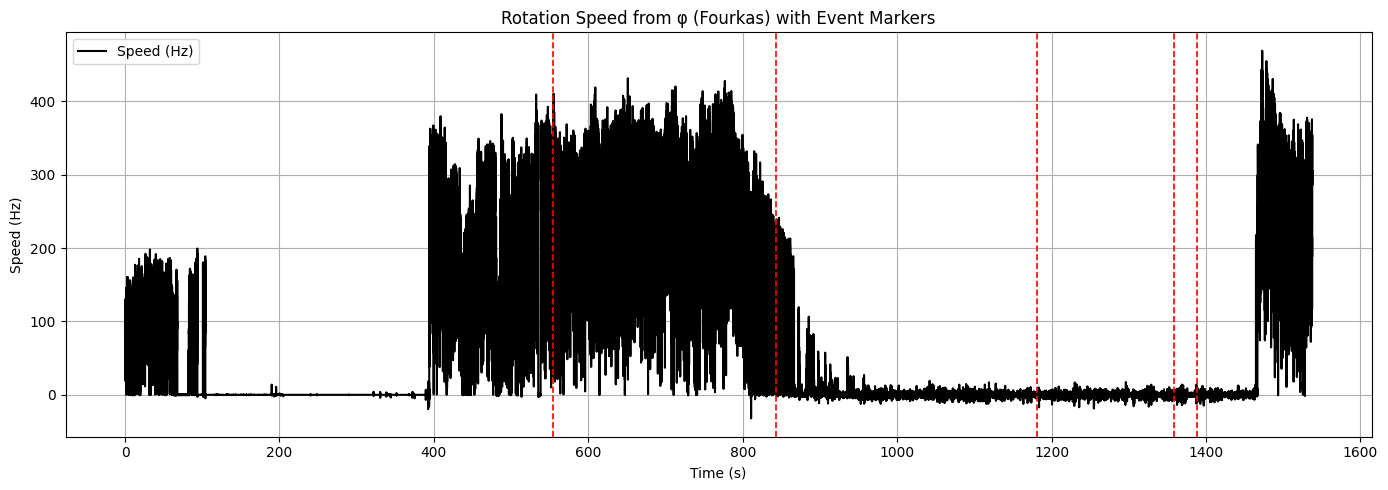

In [4]:
# Input timestamps (in seconds) to mark with vertical dashed lines
event_times = [
    0 * 60 + 6,
    0 * 60 + 42,
    1 * 60 + 10,
    8 * 60 + 22
]

# Plot
plt.figure(figsize=(14, 5))
plt.plot(t_speed, speed_hz, lw=1.5, color='black', label="Speed (Hz)")

# Add vertical dashed lines for events
for t_event in event_times:
    plt.axvline(t_event, color='red', linestyle='--', lw=1.2)

plt.xlabel("Time (s)")
plt.ylabel("Speed (Hz)")
plt.title("Rotation Speed from φ (Fourkas) with Event Markers")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig(os.path.join(os.path.dirname(npz_path), "fourkas_speed_events.png"), dpi=300)
plt.show()


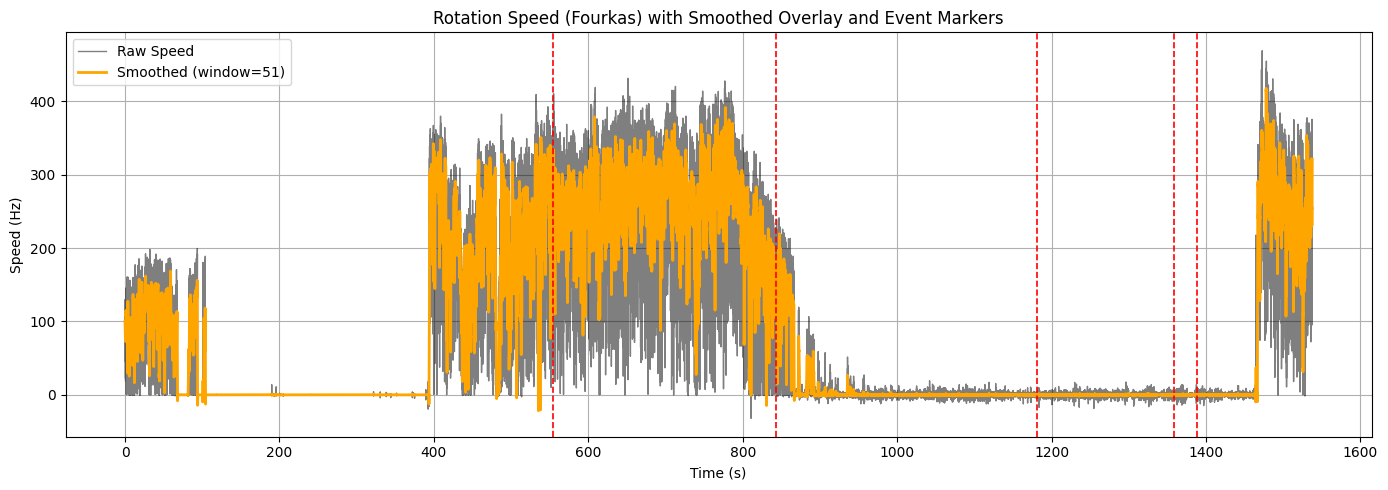

In [5]:
# Parameters for smoothing
smoothing_window = 51  # Must be odd
polyorder = 2

# Apply Savitzky-Golay smoothing
speed_smooth = savgol_filter(speed_hz, window_length=smoothing_window, polyorder=polyorder)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(t_speed, speed_hz, lw=1, alpha=0.5, label="Raw Speed", color="black")
plt.plot(t_speed, speed_smooth, lw=2, label=f"Smoothed (window={smoothing_window})", color="orange")

# Add event markers
for t_event in event_times:
    plt.axvline(t_event, color='red', linestyle='--', lw=1.2)

plt.xlabel("Time (s)")
plt.ylabel("Speed (Hz)")
plt.title("Rotation Speed (Fourkas) with Smoothed Overlay and Event Markers")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(npz_path), "fourkas_speed_smoothed_events.png"), dpi=300)
plt.show()


In [ ]:
# === Parameters ===
window_width = 10.0             # seconds of data shown per frame
scroll_step = 0.1              # step size in seconds per frame (overlap control)
fps = 10                       # frames per second
dpi = 150

# === Compute total frames to cover full data range
total_duration = t_speed[-1] - t_speed[0]
total_frames = int((total_duration - window_width) / scroll_step)

# === Set up figure
fig, ax = plt.subplots(figsize=(10, 4))
line, = ax.plot([], [], lw=2, color='black')
ax.set_ylim(np.min(speed_hz) * 0.95, np.max(speed_hz) * 1.05)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (Hz)")
ax.set_title("Fourkas Rotation Speed (1s per Frame)")
ax.grid(True)

# === Update function
def update(frame):
    start = t_speed[0] + frame * scroll_step
    end = start + window_width
    mask = (t_speed >= start) & (t_speed <= end)
    line.set_data(t_speed[mask], speed_hz[mask])
    ax.set_xlim(start, end)
    return line,

# === Create animation
ani = animation.FuncAnimation(fig, update, frames=total_frames, blit=True)

# === Save
video_path = os.path.join(os.path.dirname(npz_path), "fourkas_speed_video.mp4")
writer = FFMpegWriter(fps=fps, bitrate=1800)
ani.save(video_path, writer=writer, dpi=dpi)
plt.close()
